# GRU Seq2Seq
history_len = 30  
horizon = 5  
n_trials = 300  
lr_scheduler.CosineAnnealingLR

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join('..')))

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import optuna
from src.preprocessing import process_dataframe
from sklearn.preprocessing import StandardScaler
from src.visualization import evaluate_and_plot_full_forecast
from src.models.rnn.rnn_seq2seq import RNNSeq2Seq, Encoder, Decoder
from src.models.rnn.train_rnn_seq2seq import train_rnn_seq2seq
from src.models.rnn.data_preparing import (
    create_seq2seq_eval_loader,
    create_seq2seq_train_loader
)
from src.models.rnn.predict import predict_seq2seq
from src.seed import set_seed

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

SEED = 42
set_seed(SEED)

In [3]:
df_train_full = pd.read_csv('../data/processed/train_raw, ZK 68, (48-1, 48-air), 27.11.20-31.12.24.csv', parse_dates=['Дата'])
df_train_full.index = df_train_full['Дата']

df_test = pd.read_csv('../data/processed/test_raw, ZK 68, (48-1, 48-air), 01.01.25-15.12.25.csv', parse_dates=['Дата'])
df_test.index = df_test['Дата']

df_train = df_train_full[:'2023-12-31'].copy()
df_val = df_train_full['2024-01-01':].copy()

In [4]:
df_train_full = process_dataframe(df_train_full)
df_train = process_dataframe(df_train)
df_val = process_dataframe(df_val)
df_test = process_dataframe(df_test)

In [5]:
borehole_name = '48-1'
target_cols = ['48-1 (0)','48-1 (0,5)', '48-1 (1)', '48-1 (1,5)','48-1 (2)', '48-1 (2,5)', '48-1 (3)', 
               '48-1 (3,5)', '48-1 (4)', '48-1 (4,5)', '48-1 (5)', '48-1 (6)', '48-1 (7)', '48-1 (8)', 
               '48-1 (9)', '48-1 (10)']
feature_cols = ['Месяц_sin', 'Месяц_cos', 'day_of_year_sin', 
                 'day_of_year_cos', 'is_anomaly']

history_len = 30
horizon = 5

df_train_full = df_train_full[feature_cols + target_cols]
df_train = df_train[feature_cols + target_cols]
df_val = df_val[feature_cols + target_cols]
df_test = df_test[feature_cols + target_cols]

In [6]:
batch_size = 64

feature_scaler = StandardScaler()
target_scaler = StandardScaler()

full_feature_scaler = StandardScaler()
full_target_scaler = StandardScaler()


train_loader = create_seq2seq_train_loader(
    df=df_train,
    history_len=history_len,
    horizon=horizon,
    feature_cols=feature_cols,
    target_cols=target_cols,
    feature_scaler=feature_scaler,
    target_scaler=target_scaler,
    batch_size=batch_size
)

full_train_loader = create_seq2seq_train_loader(
    df=df_train_full,
    history_len=history_len,
    horizon=horizon,
    feature_cols=feature_cols,
    target_cols=target_cols,
    feature_scaler=full_feature_scaler,
    target_scaler=full_target_scaler,
    batch_size=batch_size
)

val_loader = create_seq2seq_eval_loader(
    df_eval=df_val,
    df_start=df_train,
    history_len=history_len,
    horizon=horizon,
    feature_cols=feature_cols,
    target_cols=target_cols,
    feature_scaler=feature_scaler,
    target_scaler=target_scaler,
    batch_size=batch_size
)

In [7]:
input_size = len(feature_cols) + len(target_cols)
feature_size = len(feature_cols)
target_size = len(target_cols)
criterion = nn.MSELoss()

def objective(trial):
    set_seed(SEED + trial.number)
    hidden_size = trial.suggest_int('hidden_size', 16, 160, step=16)
    num_layers = trial.suggest_int('num_layers', 1, 4)
    
    if num_layers == 1:
        dropout = 0.0
    else:
        dropout = trial.suggest_float('dropout', 0.0, 0.4)
    
    lr = trial.suggest_float('lr', 1e-5, 1e-3, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-5, 1e-3, log=True)
    
    t_max = trial.suggest_int('t_max', 20, 80, step=10)
    eta_min = trial.suggest_float('eta_min', 1e-7, 1e-5, log=True)
    
    encoder_trial = Encoder(
        input_size=input_size,
        hidden_size=hidden_size,
        num_layers=num_layers,
        dropout=dropout,
        rnn_type='gru'
    )
    
    decoder_trial = Decoder(
        feature_size=feature_size,
        target_size=target_size,
        hidden_size=hidden_size,
        num_layers=num_layers,
        dropout=dropout,
        rnn_type='gru'
    )
    
    model_trial = RNNSeq2Seq(
        encoder=encoder_trial,
        decoder=decoder_trial,
        target_size=len(target_cols)
    ).to(device)
    
    optimizer_trial = optim.AdamW(
        model_trial.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer_trial,
        T_max=t_max,
        eta_min=eta_min
    )
    model_trial, history = train_rnn_seq2seq(
        model=model_trial,
        criterion=criterion,
        optimizer=optimizer_trial,
        train_loader=train_loader,
        val_loader=val_loader,
        teacher_forcing_ratio=0.5,
        scheduler=scheduler,
        device=device,
        epochs=200,
        max_epochs_no_improvement=15,
        verbose=False
    )
    
    trial.set_user_attr('actual_dropout', dropout)
    trial.set_user_attr('best_epoch', history['best_epoch'])
    trial.set_user_attr('total_epochs', len(history['val_rmse']))
    
    best_val_rmse = float(history['best_val_rmse'][-1])
    return best_val_rmse

sampler = optuna.samplers.TPESampler(seed=SEED)
study = optuna.create_study(direction='minimize', sampler=sampler)
study.optimize(objective, n_trials=300)

print('Лучшие параметры: ', study.best_params)
print('Количество эпох в лучшем запуске: ', study.best_trial.user_attrs['total_epochs'])

[I 2026-06-19 17:16:28,370] A new study created in memory with name: no-name-464b254d-ad36-4916-894e-c47b9d8def12
[I 2026-06-19 17:16:54,511] Trial 0 finished with value: 0.12874694168567657 and parameters: {'hidden_size': 64, 'num_layers': 4, 'dropout': 0.292797576724562, 'lr': 0.00015751320499779721, 'weight_decay': 2.0513382630874486e-05, 't_max': 30, 'eta_min': 1.3066739238053266e-07}. Best is trial 0 with value: 0.12874694168567657.


Early stopping on 93 epoch


[I 2026-06-19 17:17:46,766] Trial 1 finished with value: 0.14379501342773438 and parameters: {'hidden_size': 144, 'num_layers': 3, 'dropout': 0.2832290311184182, 'lr': 1.0994335574766187e-05, 'weight_decay': 0.0008706020878304854, 't_max': 70, 'eta_min': 2.6587543983272685e-07}. Best is trial 0 with value: 0.12874694168567657.
[I 2026-06-19 17:18:18,490] Trial 2 finished with value: 0.25538188219070435 and parameters: {'hidden_size': 32, 'num_layers': 1, 'lr': 4.059611610484306e-05, 'weight_decay': 0.00011207606211860574, 't_max': 50, 'eta_min': 3.8234752246751824e-07}. Best is trial 0 with value: 0.12874694168567657.
[I 2026-06-19 17:18:50,103] Trial 3 finished with value: 0.13329441845417023 and parameters: {'hidden_size': 112, 'num_layers': 1, 'lr': 3.8396292998041685e-05, 'weight_decay': 5.4041038546473305e-05, 't_max': 50, 'eta_min': 3.7183641805732028e-06}. Best is trial 0 with value: 0.12874694168567657.
[I 2026-06-19 17:19:36,785] Trial 4 finished with value: 0.5307095050811768

Early stopping on 64 epoch


[I 2026-06-19 17:20:28,977] Trial 6 finished with value: 0.08898346871137619 and parameters: {'hidden_size': 32, 'num_layers': 2, 'dropout': 0.013755408446087358, 'lr': 0.000658628931758311, 'weight_decay': 3.292759134423613e-05, 't_max': 60, 'eta_min': 4.2016720543725276e-07}. Best is trial 6 with value: 0.08898346871137619.


...

Early stopping on 117 epoch


[I 2026-06-19 19:28:10,289] Trial 298 finished with value: 0.08005446195602417 and parameters: {'hidden_size': 48, 'num_layers': 1, 'lr': 0.0005327881196538147, 'weight_decay': 0.00026719079297625936, 't_max': 70, 'eta_min': 1.236613444077655e-06}. Best is trial 144 with value: 0.06258980184793472.


Early stopping on 172 epoch


[I 2026-06-19 19:28:39,141] Trial 299 finished with value: 0.07461610436439514 and parameters: {'hidden_size': 128, 'num_layers': 1, 'lr': 0.0004841610561099421, 'weight_decay': 9.378832129224458e-05, 't_max': 70, 'eta_min': 3.7306342444875107e-06}. Best is trial 144 with value: 0.06258980184793472.


Early stopping on 137 epoch
Лучшие параметры:  {'hidden_size': 160, 'num_layers': 1, 'lr': 0.00048694162405672905, 'weight_decay': 0.00022088881975481552, 't_max': 70, 'eta_min': 8.247978427543717e-07}
Количество эпох в лучшем запуске:  200


In [8]:
encoder = Encoder(
    input_size=input_size,
    hidden_size=study.best_params['hidden_size'],
    num_layers=study.best_params['num_layers'],
    dropout=study.best_trial.user_attrs['actual_dropout'],
    rnn_type='gru'
)

decoder = Decoder(
    feature_size=feature_size,
    target_size=target_size,
    hidden_size=study.best_params['hidden_size'],
    num_layers=study.best_params['num_layers'],
    dropout=study.best_trial.user_attrs['actual_dropout'],
    rnn_type='gru'
)

model = RNNSeq2Seq(
    encoder=encoder,
    decoder=decoder,
    target_size=len(target_cols)
).to(device)
optimizer = optim.AdamW(
    model.parameters(),
    lr=study.best_params['lr'],
    weight_decay=study.best_params['weight_decay']
)
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=study.best_params['t_max'],
    eta_min=study.best_params['eta_min']
)

model, _ = train_rnn_seq2seq(
    model=model,
    criterion=criterion,
    optimizer=optimizer,
    train_loader=train_loader,
    teacher_forcing_ratio=0.5,
    scheduler=scheduler,
    device=device,
    epochs=study.best_trial.user_attrs['best_epoch'],
    max_epochs_no_improvement=15,
    verbose=True
)

Epoch 1/195 | Train Loss: 0.8306
Epoch 2/195 | Train Loss: 0.2843
Epoch 3/195 | Train Loss: 0.1037
Epoch 4/195 | Train Loss: 0.0609
Epoch 5/195 | Train Loss: 0.0376
Epoch 6/195 | Train Loss: 0.0299
Epoch 7/195 | Train Loss: 0.0304
Epoch 8/195 | Train Loss: 0.0247
Epoch 9/195 | Train Loss: 0.0230
Epoch 10/195 | Train Loss: 0.0198
Epoch 11/195 | Train Loss: 0.0183
Epoch 12/195 | Train Loss: 0.0180
Epoch 13/195 | Train Loss: 0.0157
Epoch 14/195 | Train Loss: 0.0147
Epoch 15/195 | Train Loss: 0.0139
Epoch 16/195 | Train Loss: 0.0127
Epoch 17/195 | Train Loss: 0.0126
Epoch 18/195 | Train Loss: 0.0118
Epoch 19/195 | Train Loss: 0.0111
Epoch 20/195 | Train Loss: 0.0103
Epoch 21/195 | Train Loss: 0.0099
Epoch 22/195 | Train Loss: 0.0092
Epoch 23/195 | Train Loss: 0.0091
Epoch 24/195 | Train Loss: 0.0094
Epoch 25/195 | Train Loss: 0.0081
Epoch 26/195 | Train Loss: 0.0077
Epoch 27/195 | Train Loss: 0.0078
Epoch 28/195 | Train Loss: 0.0072
Epoch 29/195 | Train Loss: 0.0074
Epoch 30/195 | Train Lo

In [ ]:
model_path = 'models/gru_seq2seq_v4_optuna.pth'
weights_path = 'models/gru_seq2seq_v4_optuna_weights.pth'

torch.save(model, model_path)
torch.save(model.state_dict(), weights_path)

model = torch.load(model_path, weights_only=False)

                              RMSE      MAE        ME       NSE
Значение для всех глубин  0.617004  0.48004 -0.087845  0.969087


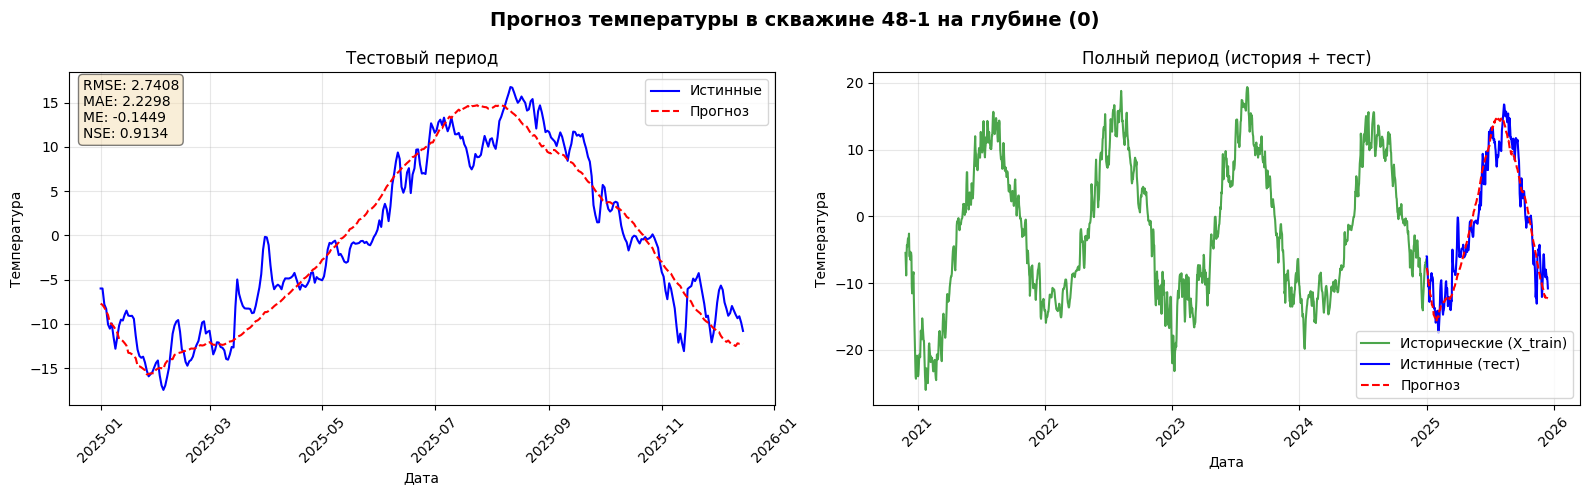

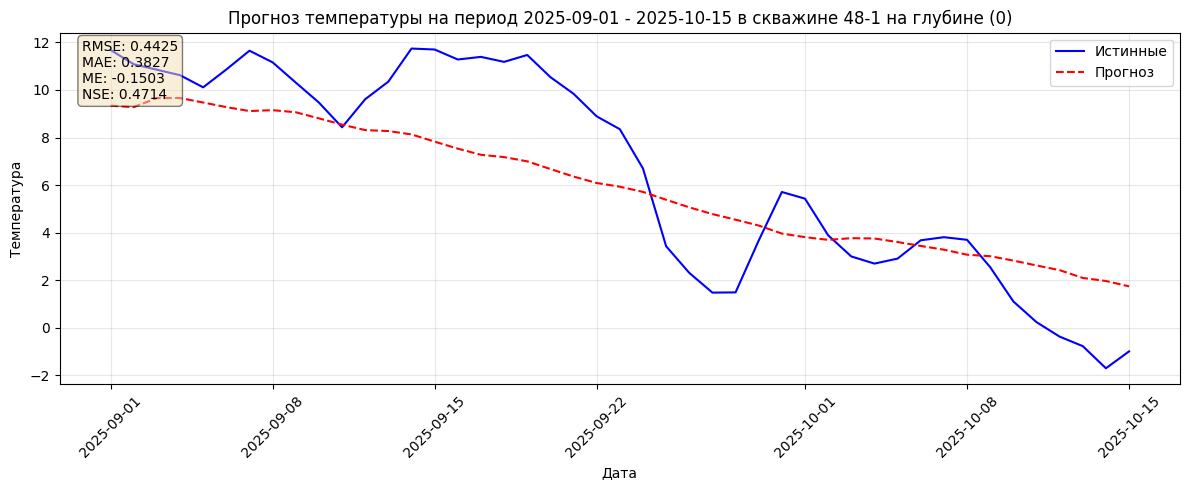

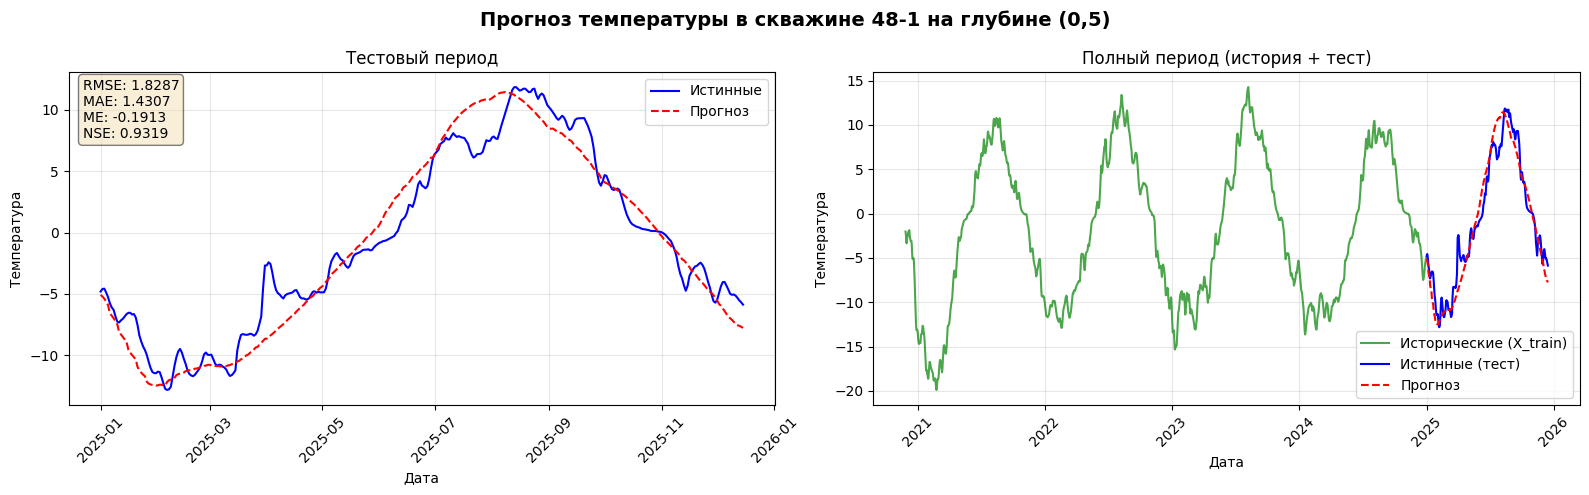

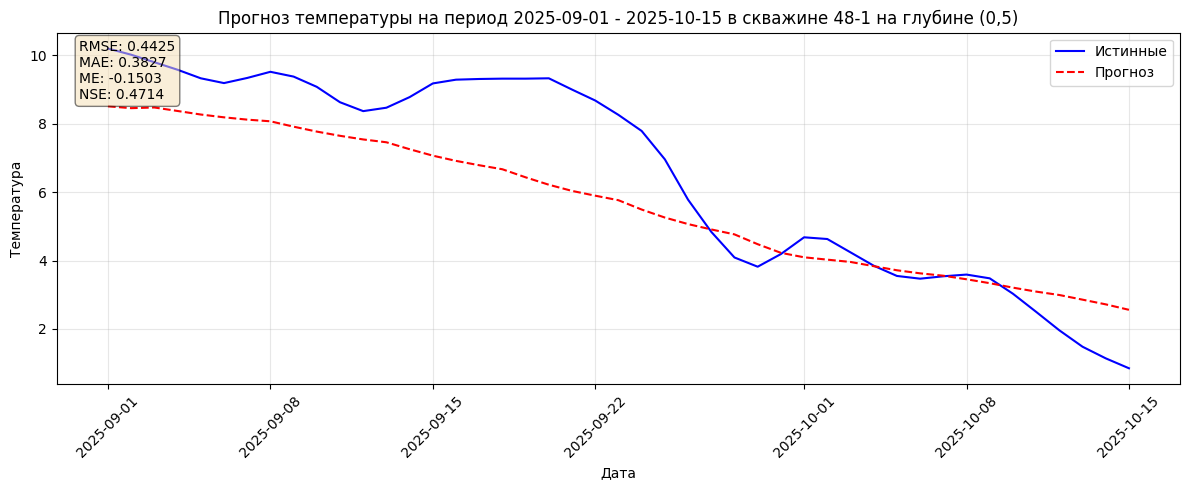

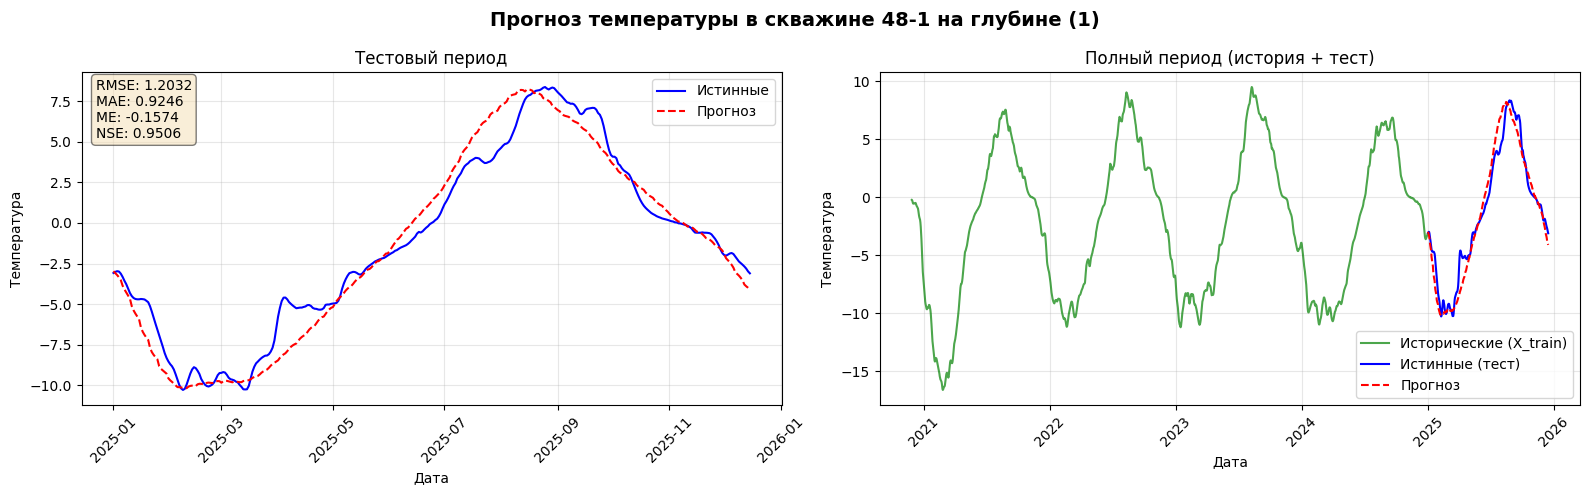

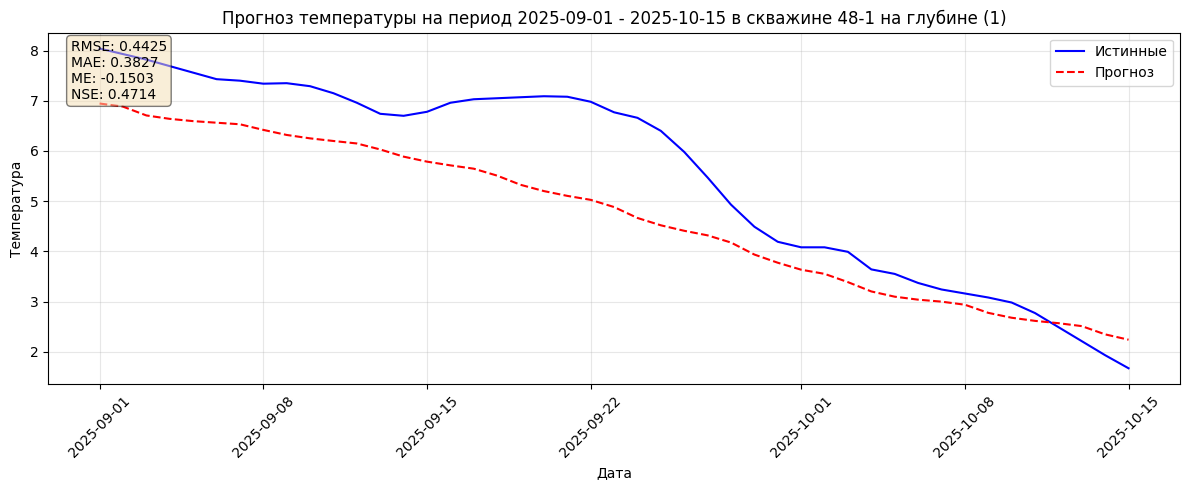

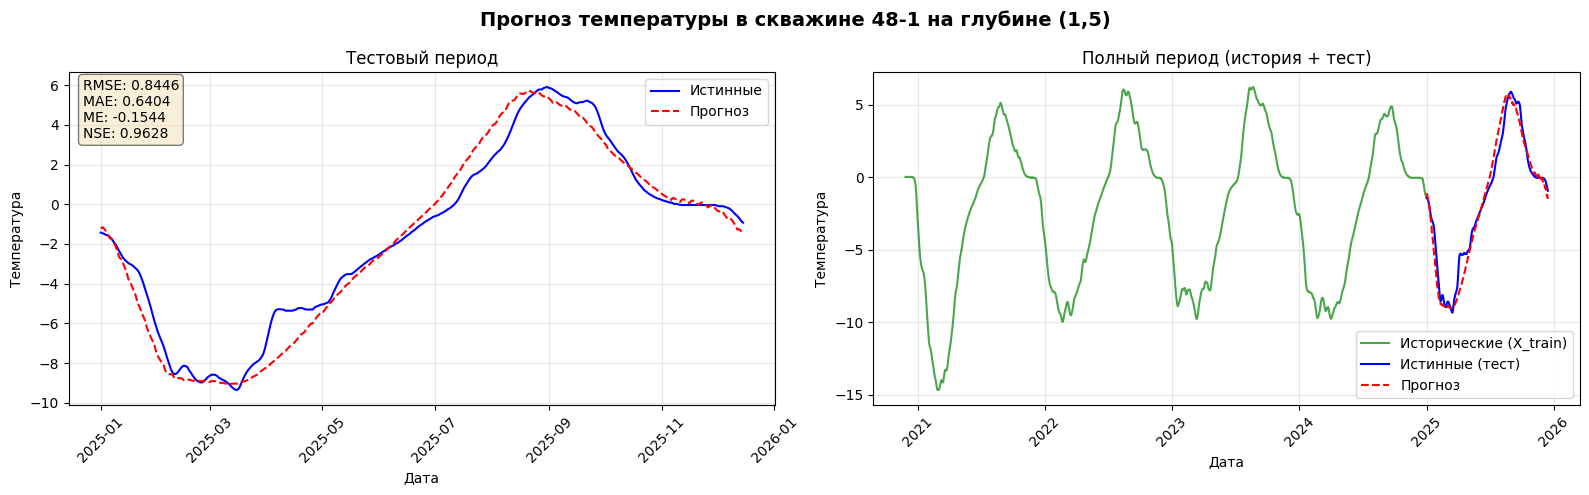

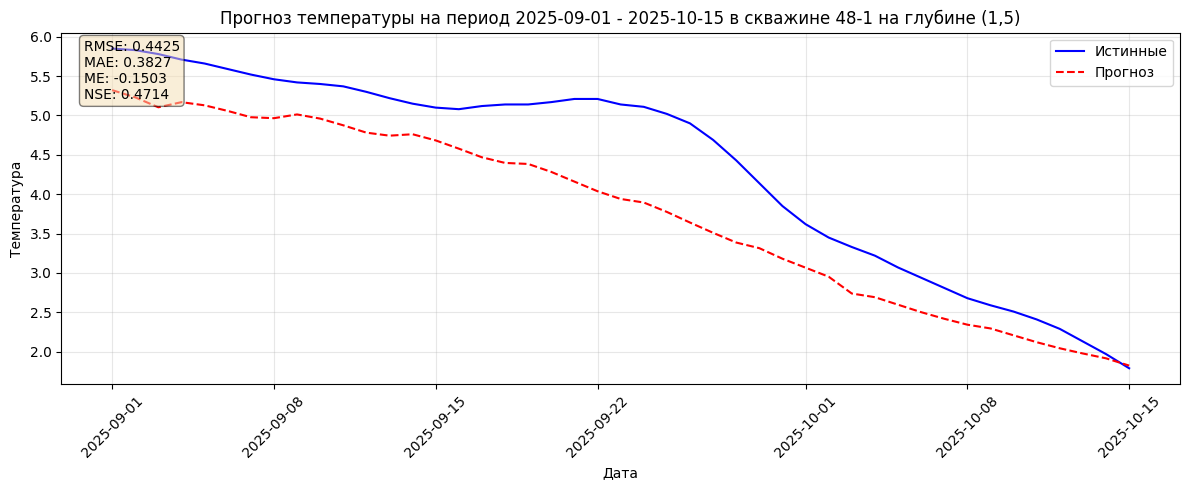

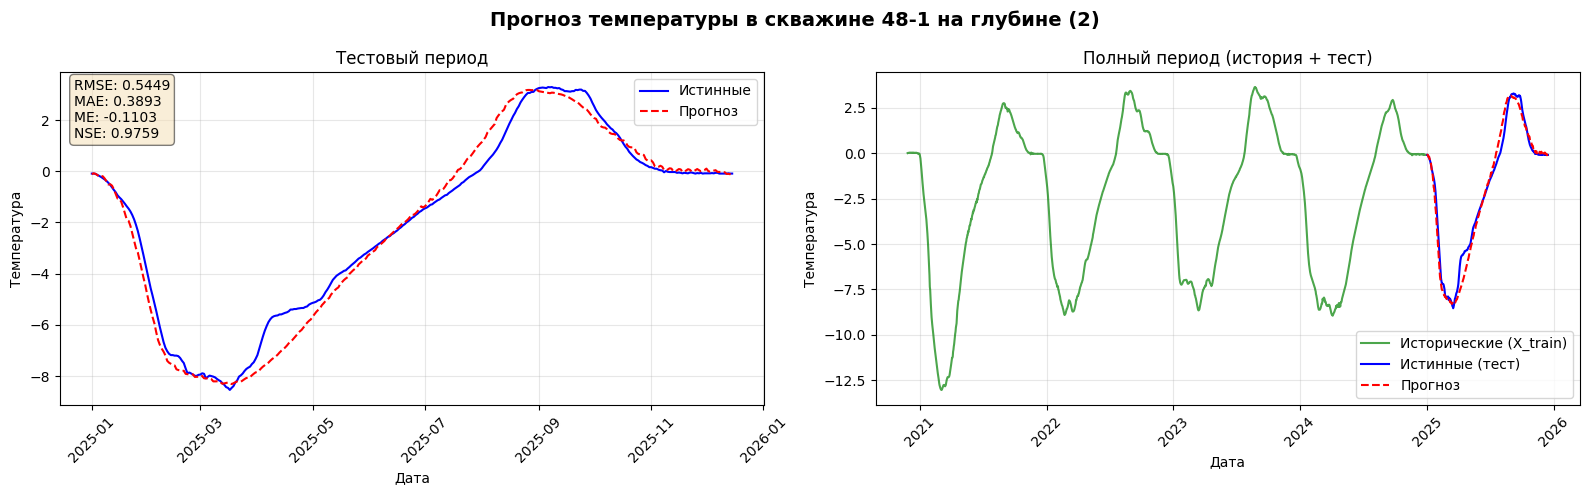

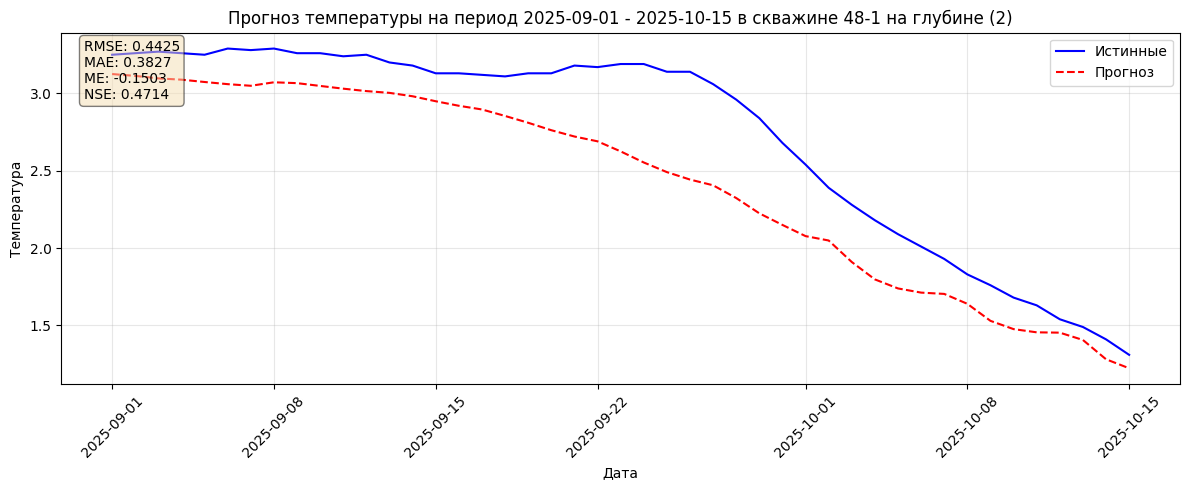

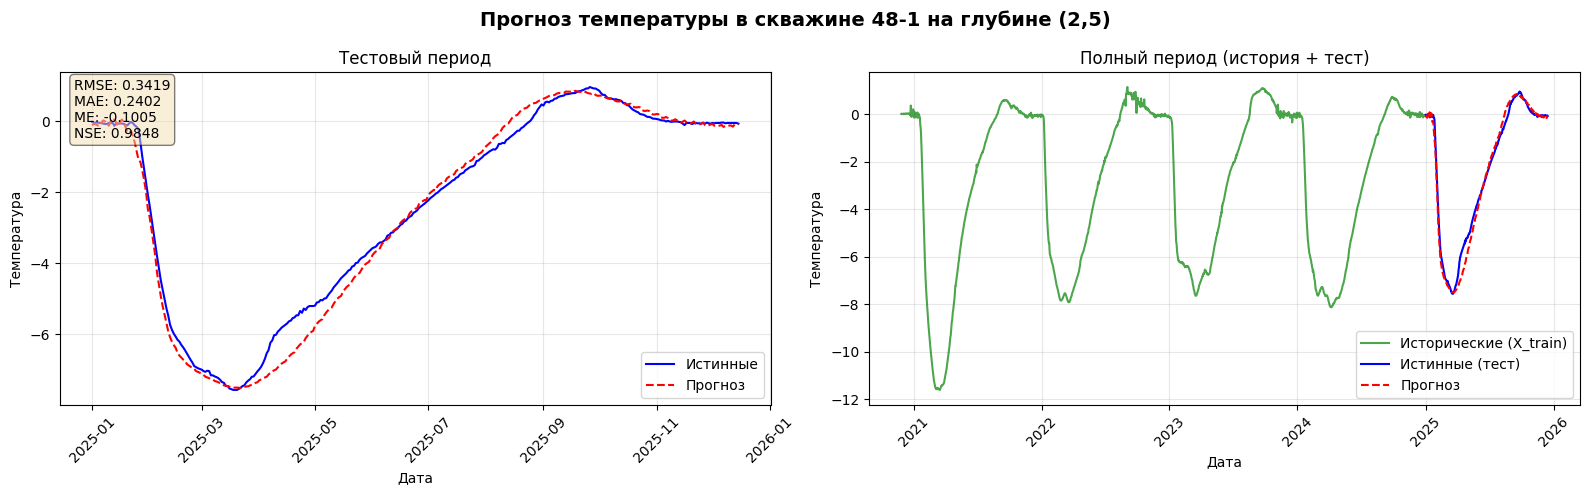

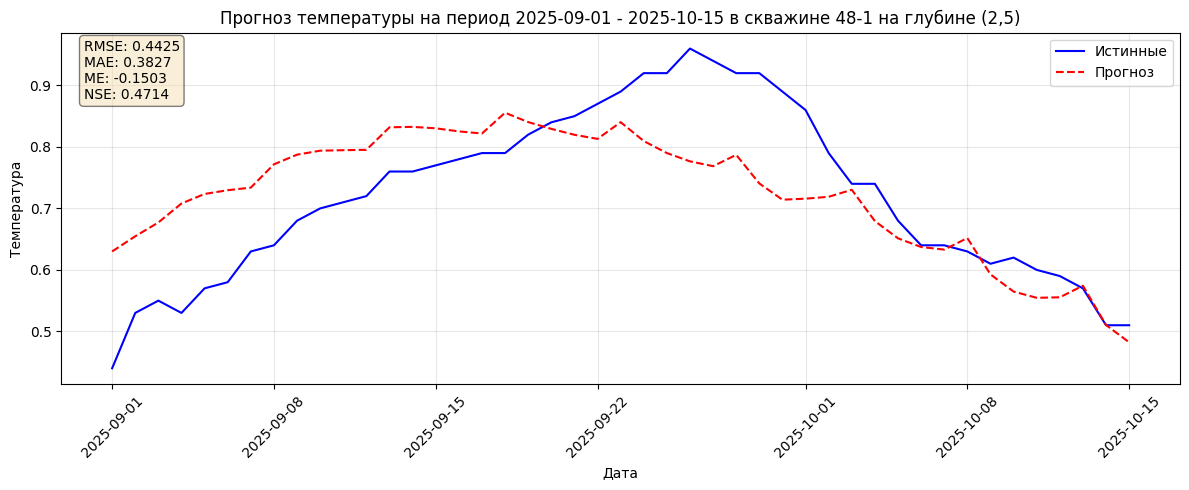

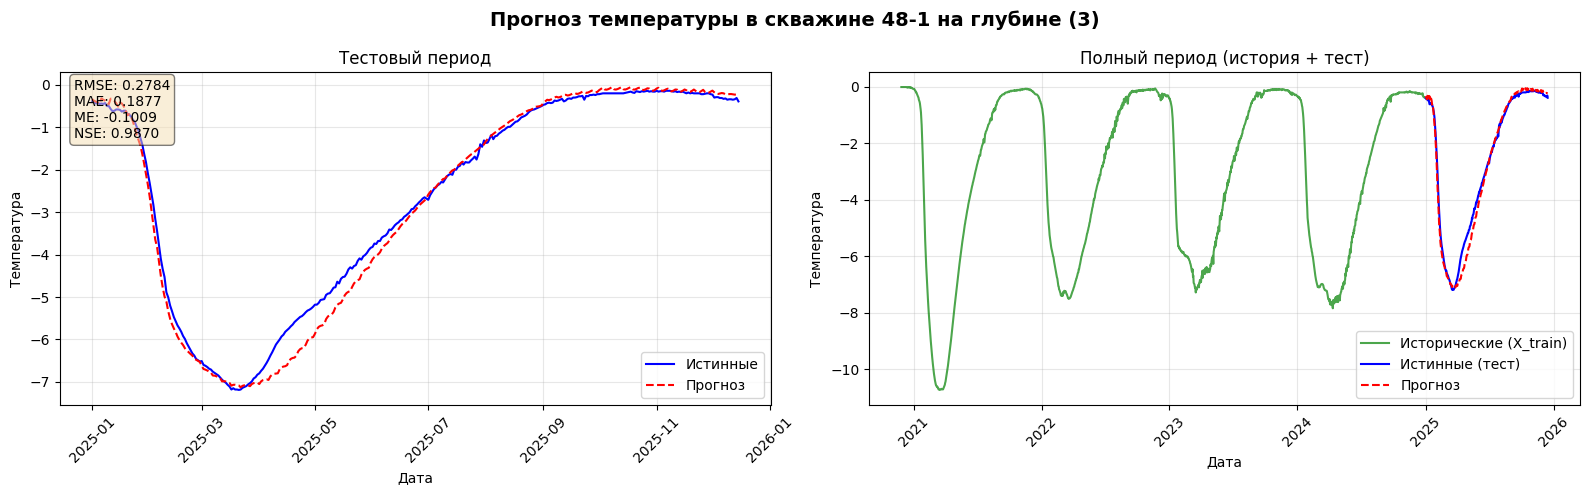

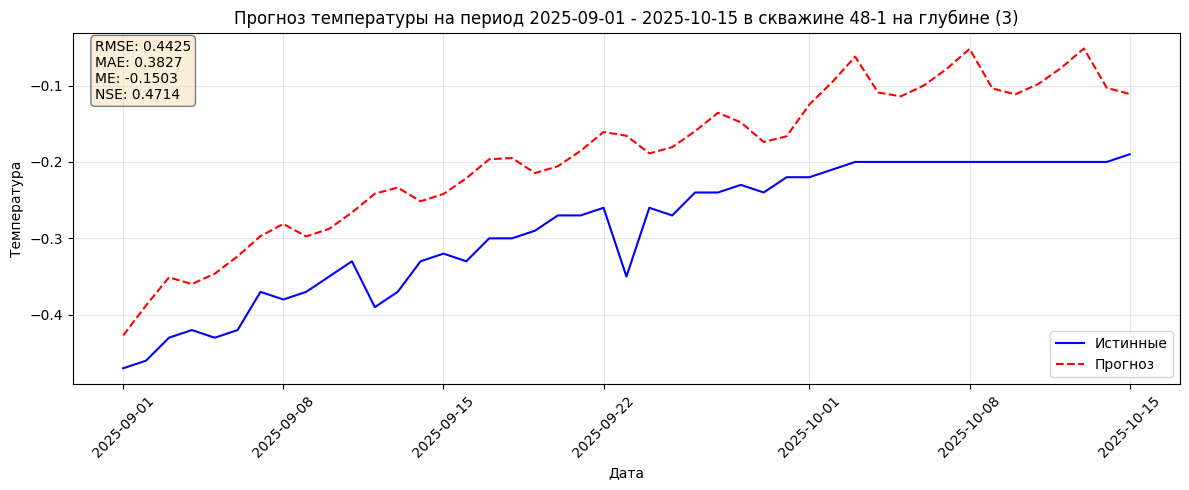

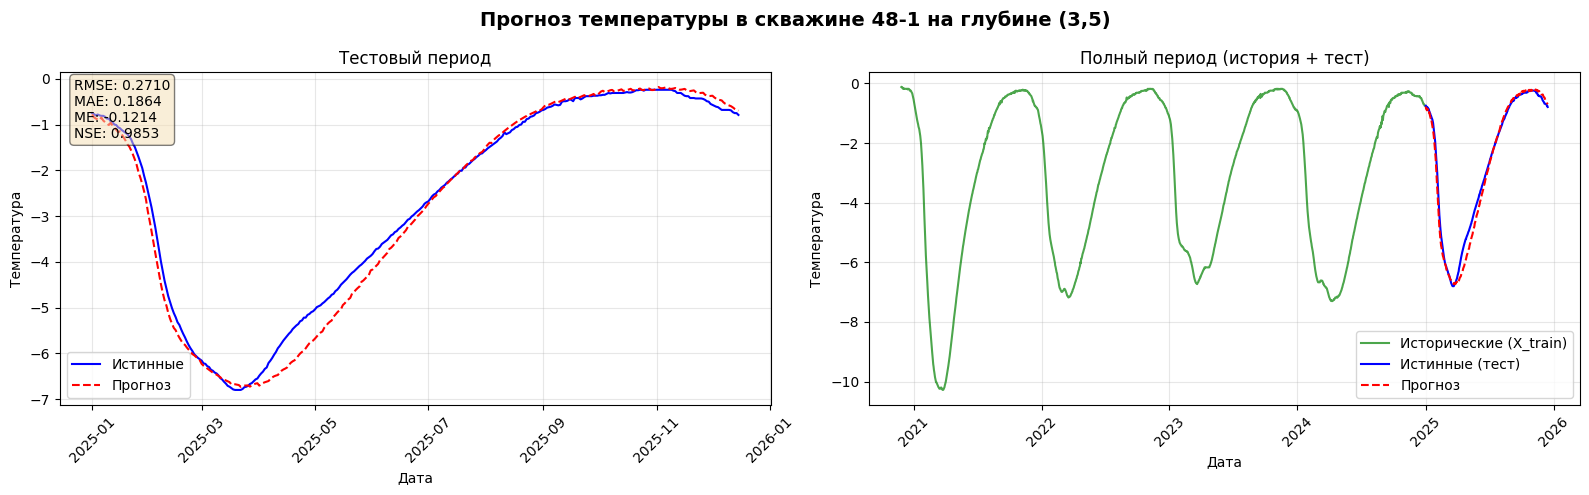

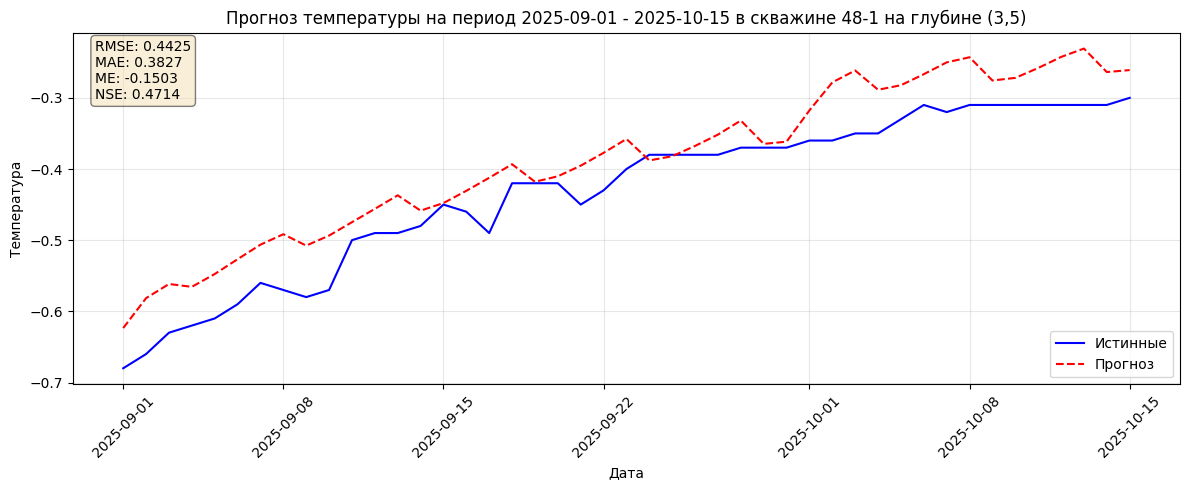

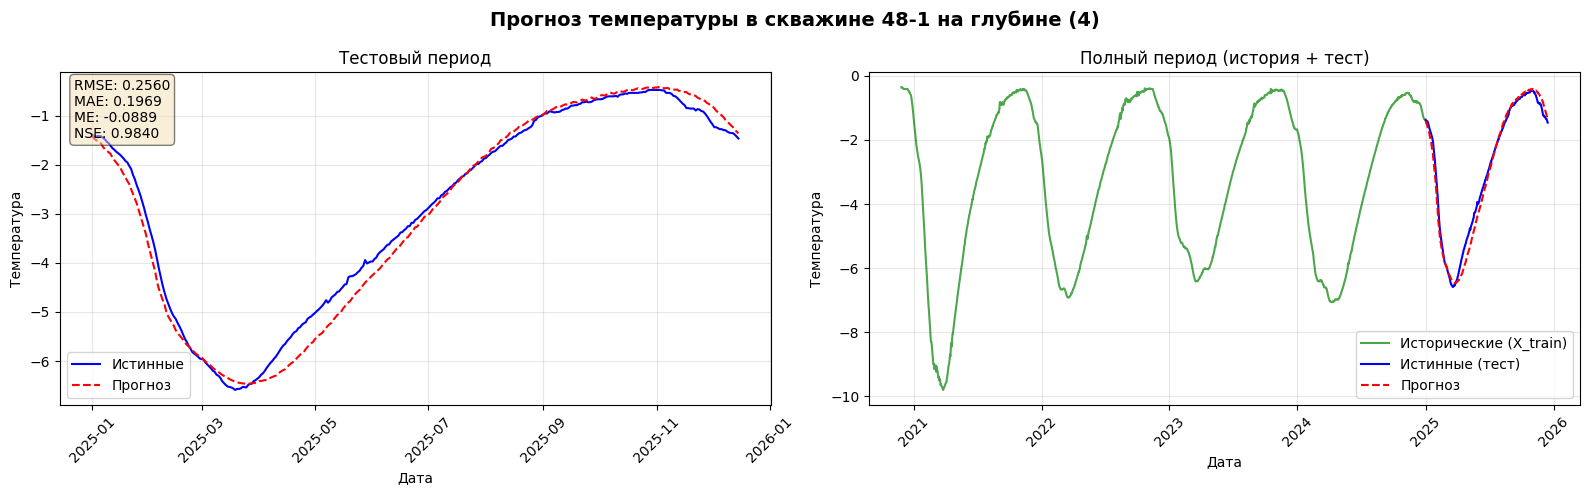

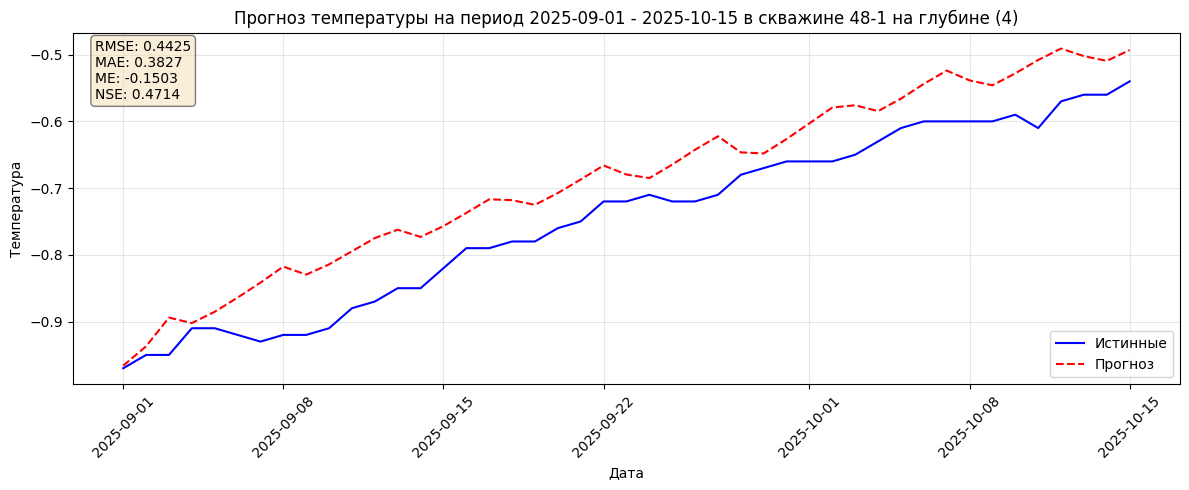

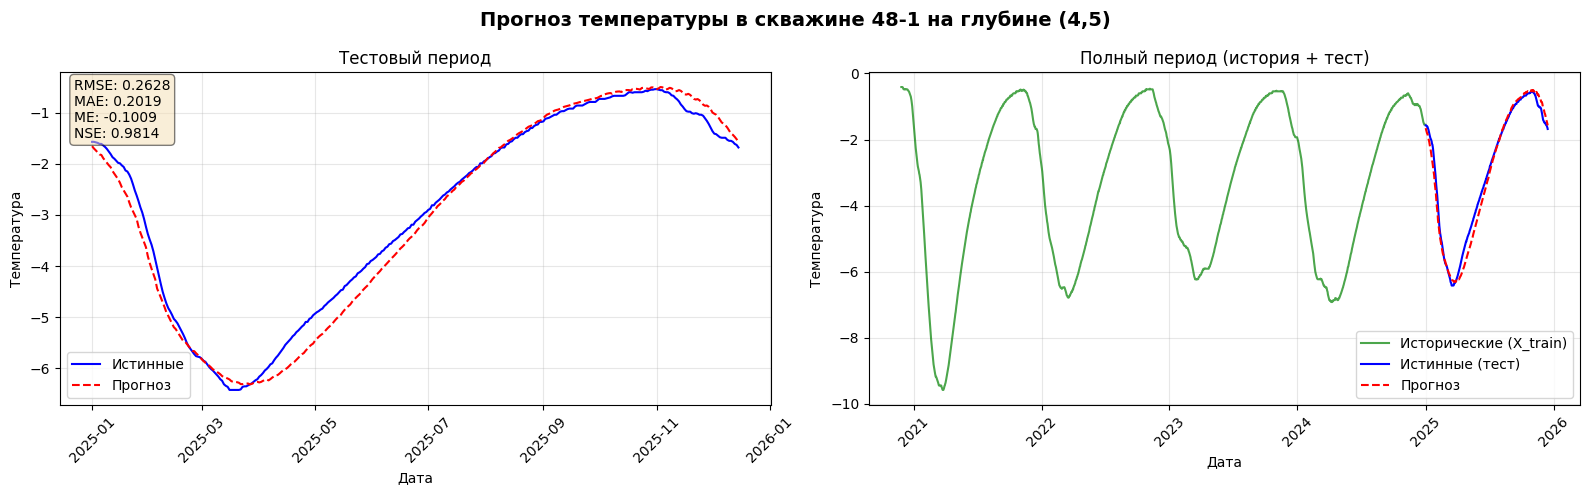

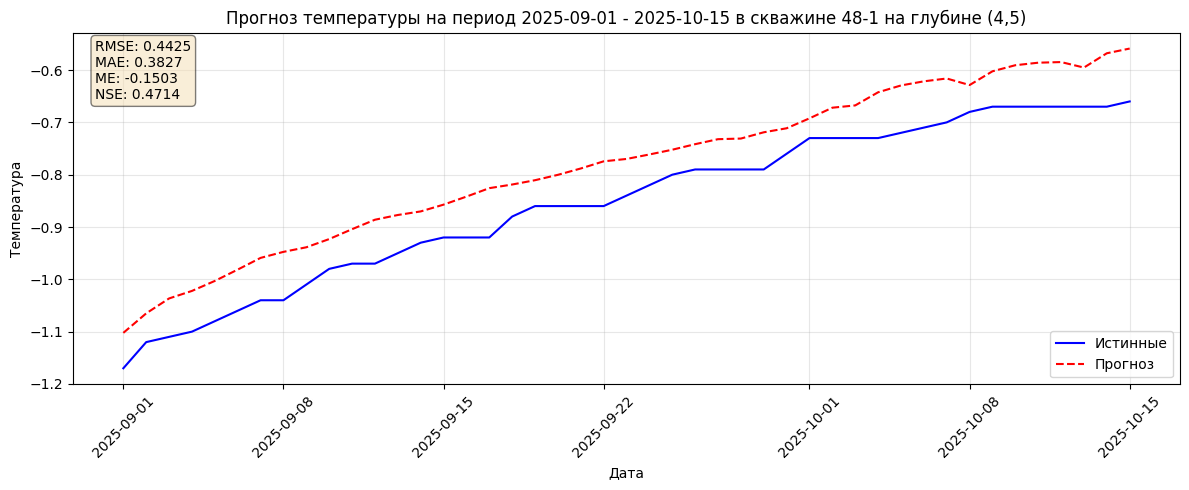

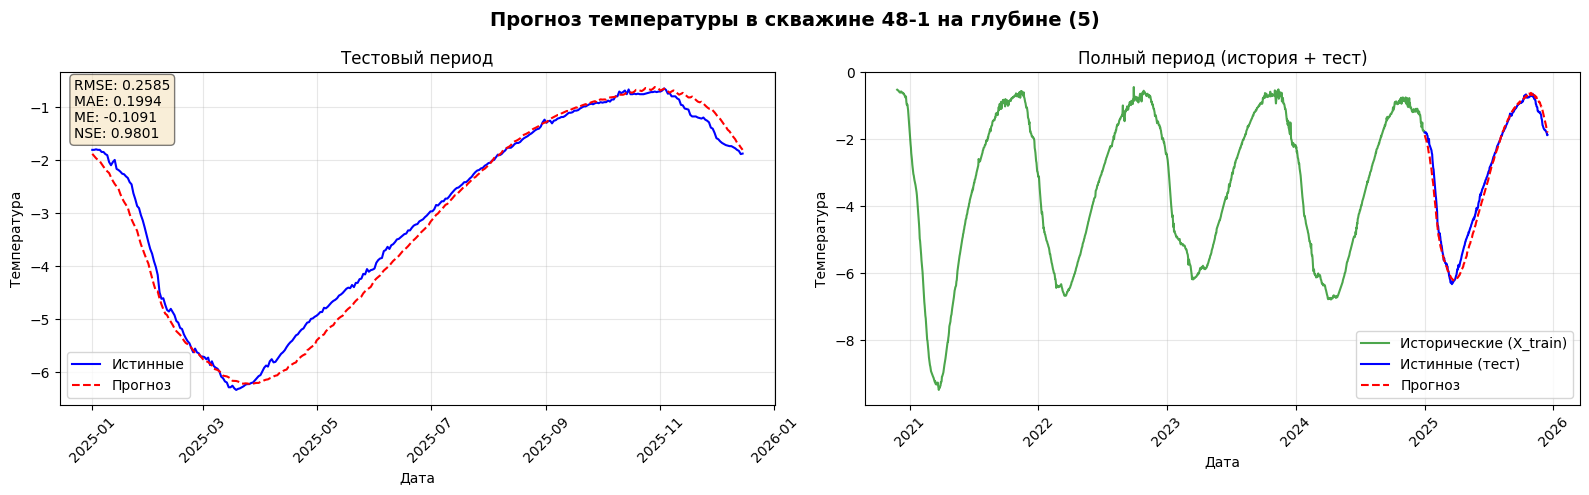

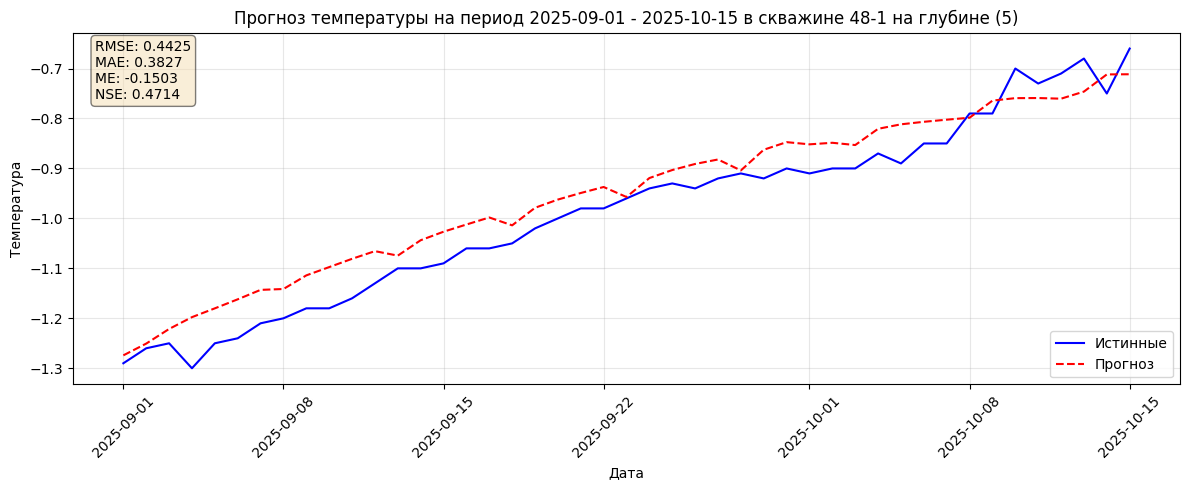

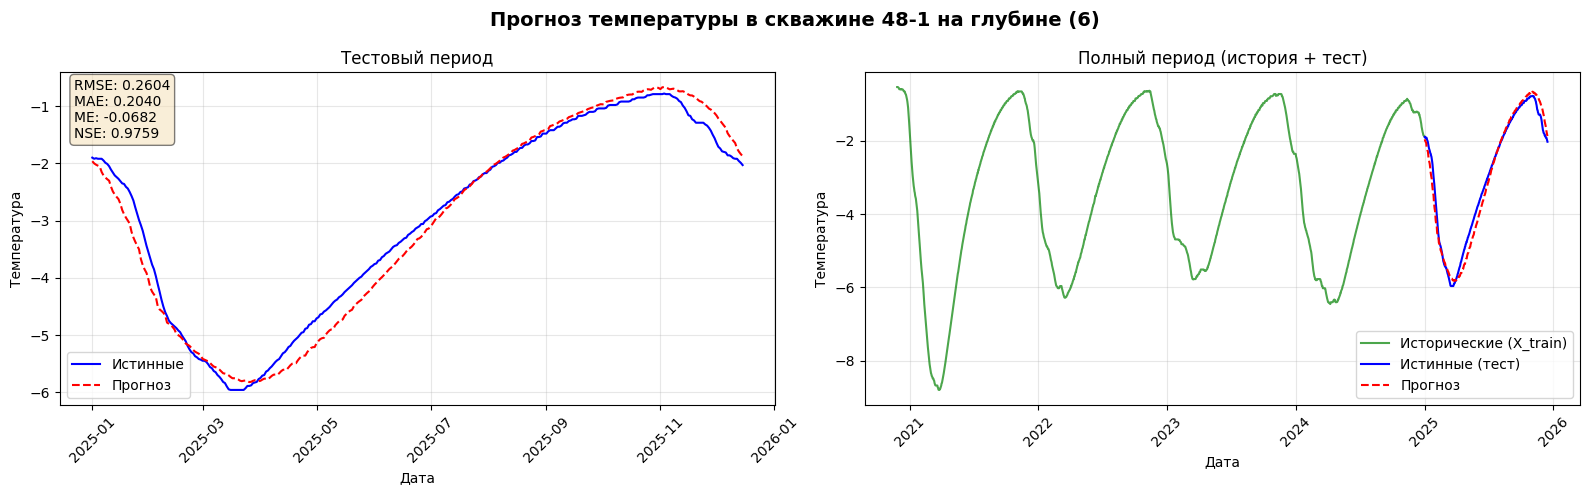

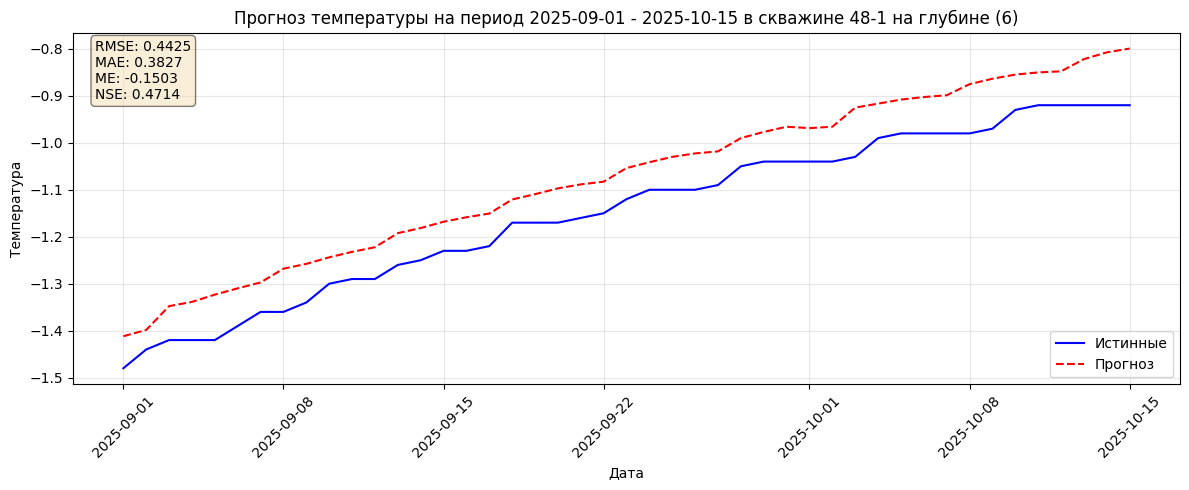

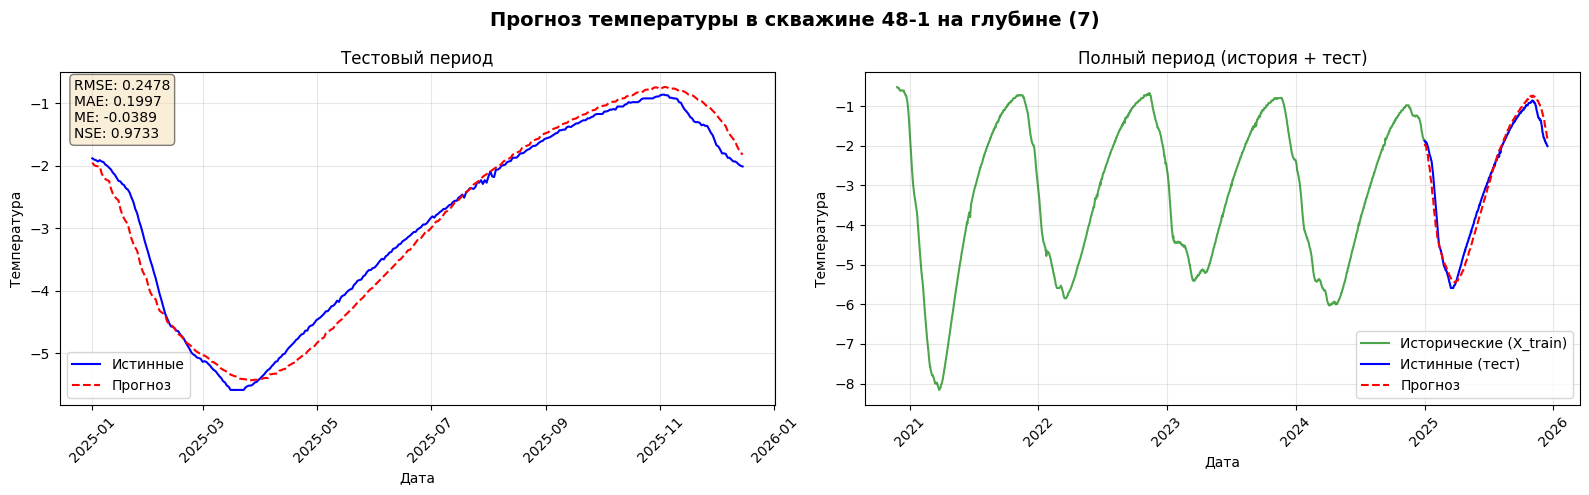

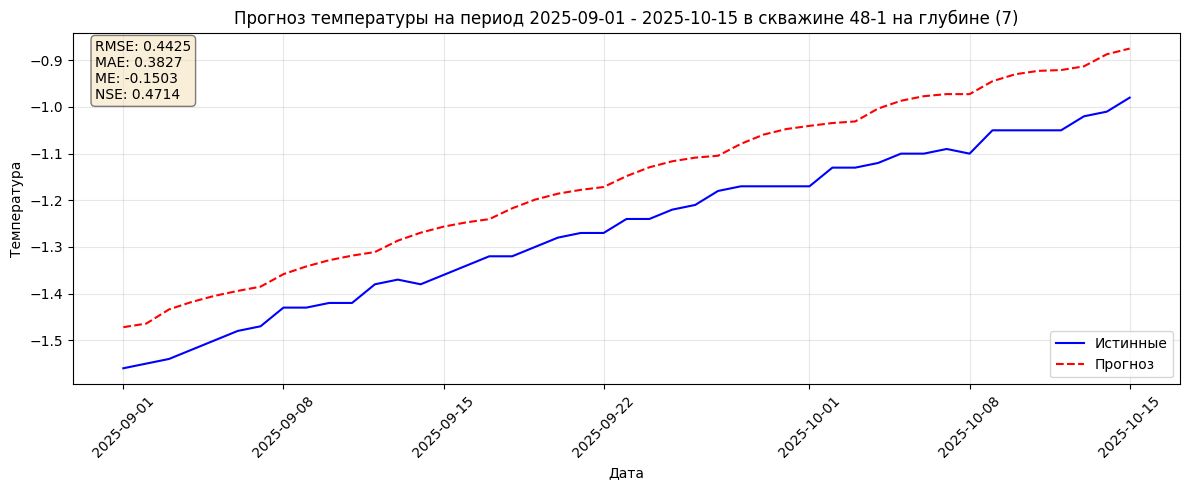

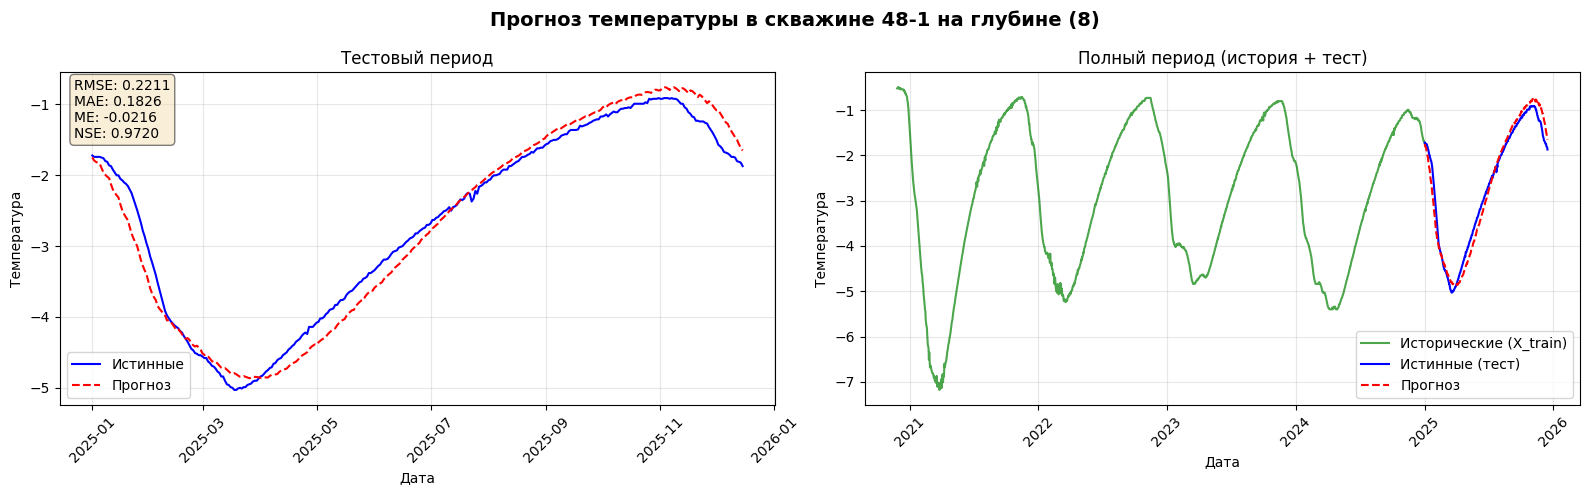

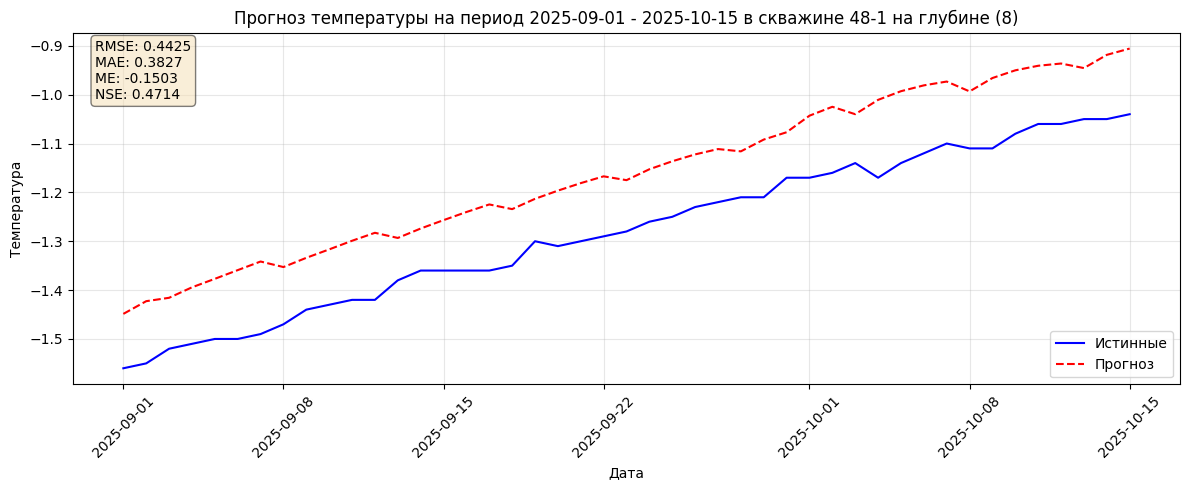

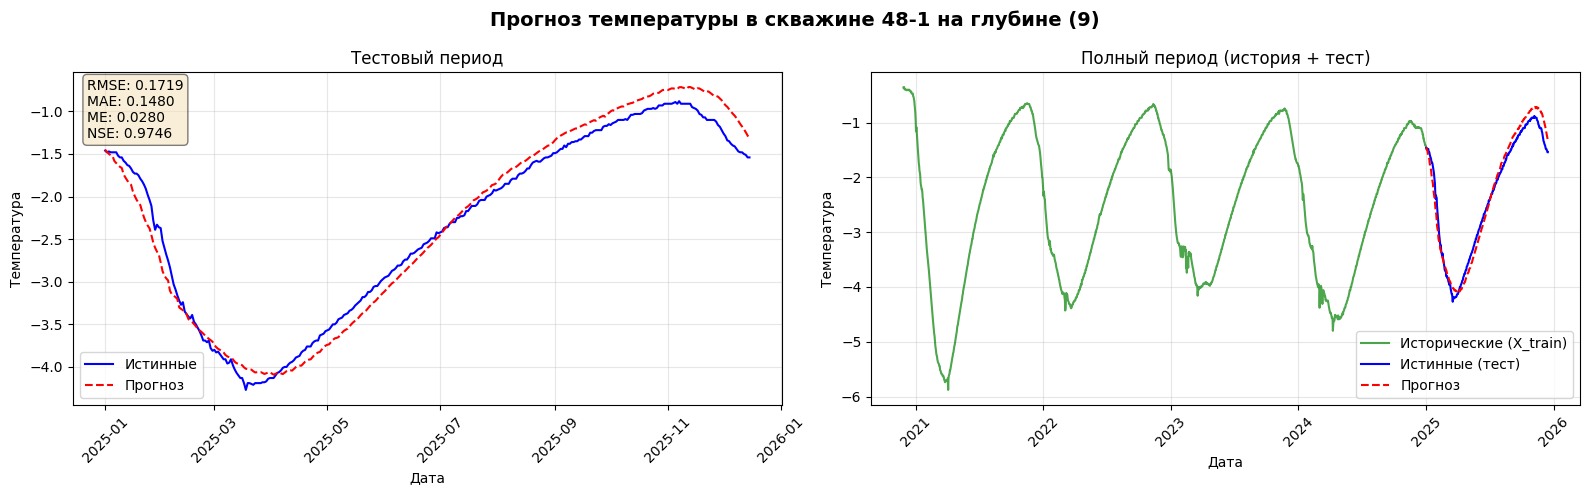

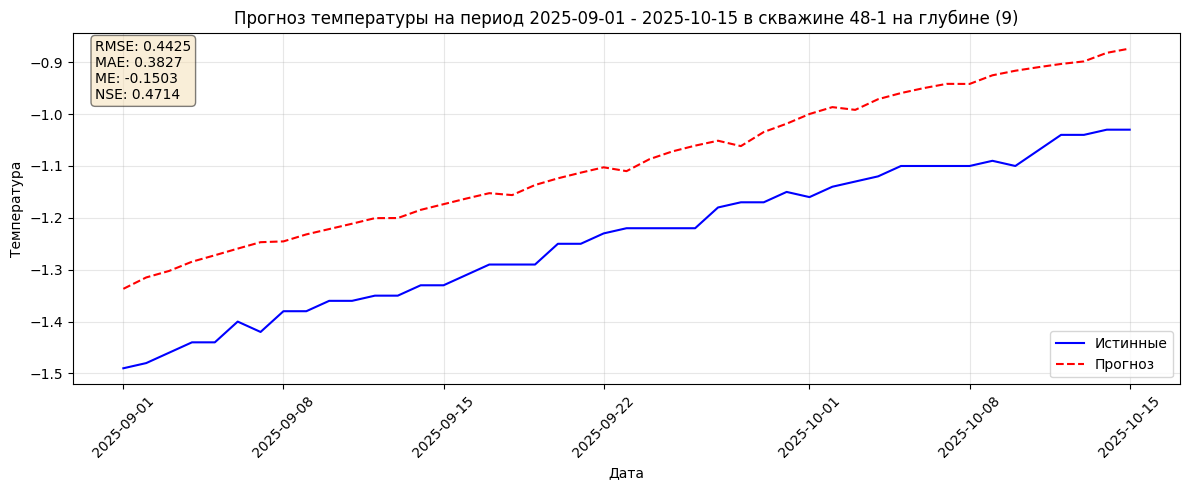

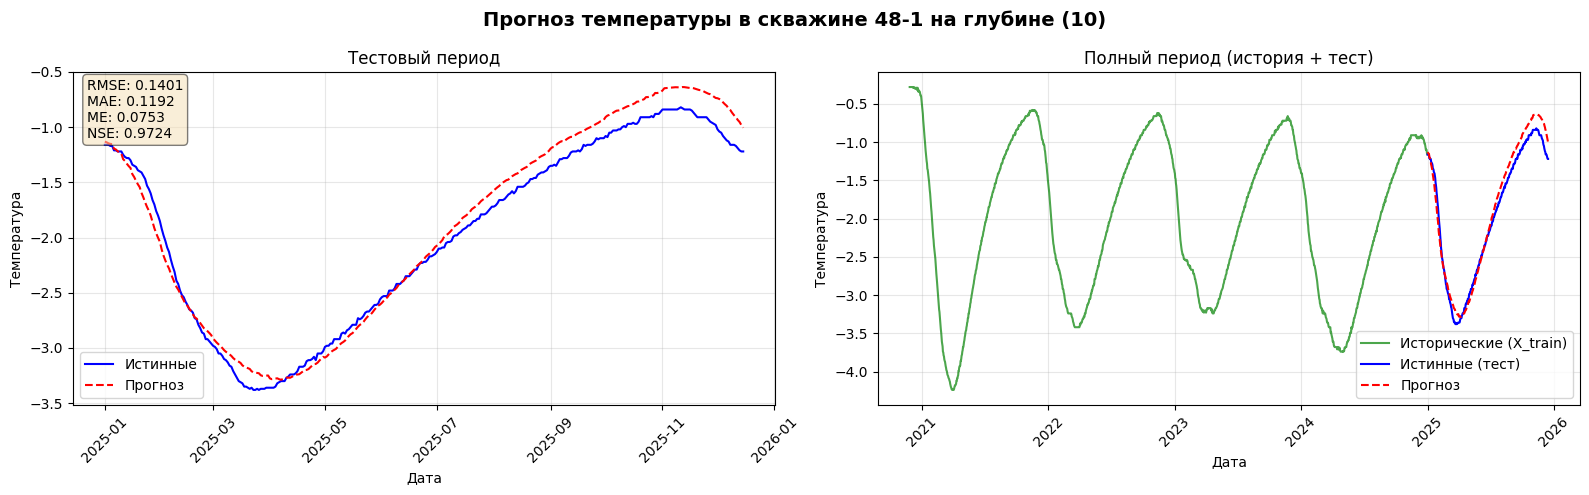

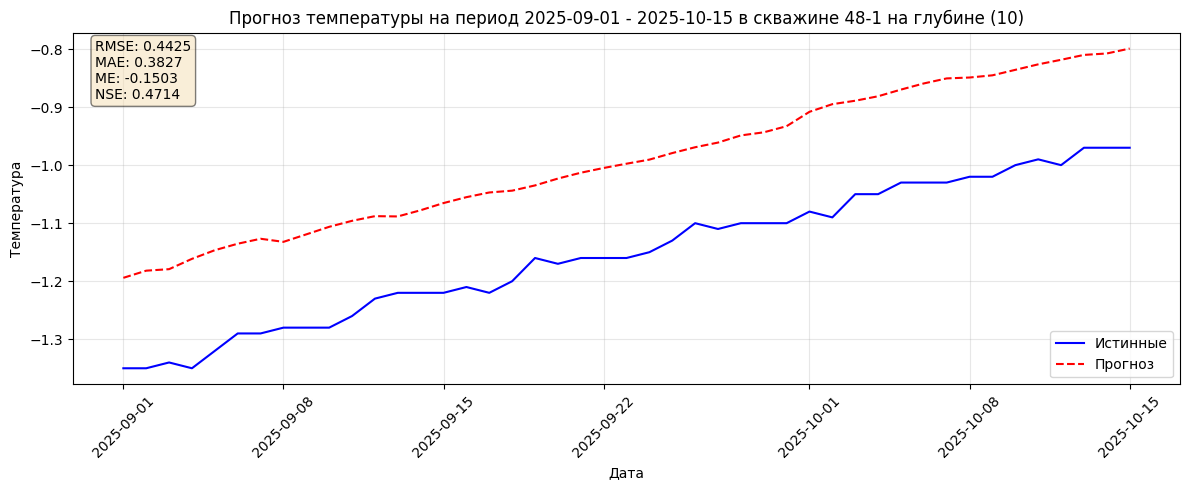

In [10]:
y_pred = predict_seq2seq(
    model=model,
    df_history=df_val,
    df_test=df_test,
    feature_scaler=feature_scaler,
    target_scaler=target_scaler,
    feature_cols=feature_cols,
    target_cols=target_cols,
    history_len=history_len,
    horizon=horizon,
    device=device,
)
y_true = df_test[target_cols]

evaluate_and_plot_full_forecast(
    y_true=y_true,
    y_pred=y_pred,
    target_cols=target_cols,
    df_train_full=df_train_full,
    required_interval=('2025-09-01', '2025-10-15'),
    borehole_name=borehole_name
)